In [1]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 129.0 MB/s eta 0:00:00


In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="E9Pyxhe86Ve7S2UDXHPT")
project = rf.workspace("ayesha-ovgn4").project("abnormal-behaviour")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Abnormal-behaviour-1 in folder:: 100%|██████████| 13991/13991 [00:01<00:00, 9285.23it/s]


In [3]:
import os

print(os.listdir(dataset.location))

['valid', 'train', 'README.roboflow.txt', 'README.dataset.txt', 'test']


In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

results = model.train(
    data=dataset.location,
    epochs=5,
    imgsz=224,
    batch=32,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Abnormal-behaviour-1, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015

In [5]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,443,847 parameters, 0 gradients, 3.3 GFLOPs
train: /content/Abnormal-behaviour-1/train... found 12888 images in 7 classes ✅ 
val: /content/Abnormal-behaviour-1/valid... found 539 images in 7 classes ✅ 
test: /content/Abnormal-behaviour-1/test... found 538 images in 7 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 269.5±91.0 MB/s, size: 9.0 KB)
val: Scanning /content/Abnormal-behaviour-1/valid... 539 images, 0 corrupt: 100% ━━━━━━━━━━━━ 539/539 141.3Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 34/34 14.8it/s 2.3s
                   all      0.968          1
Speed: 0.4ms preprocess, 2.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79

In [12]:
results = model.predict(
    source="IMG20240629184956.jpg",
    save=True,
    conf=0.25
)


image 1/1 /content/IMG20240629184956.jpg: 224x224 Kicking 0.60, Punching 0.18, Fight 0.09, Falling 0.07, Cheating 0.06, 3.0ms
Speed: 64.5ms preprocess, 3.0ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/classify/predict


In [13]:
print(results[0].names)
print(results[0].probs.top1)

{0: 'Cheating', 1: 'Falling', 2: 'Fight', 3: 'Fleeing', 4: 'Kicking', 5: 'Punching', 6: 'Pushing'}
4


In [14]:
from google.colab import files
files.download("runs/classify/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(np.float64(-0.5), np.float64(1199.5), np.float64(1199.5), np.float64(-0.5))

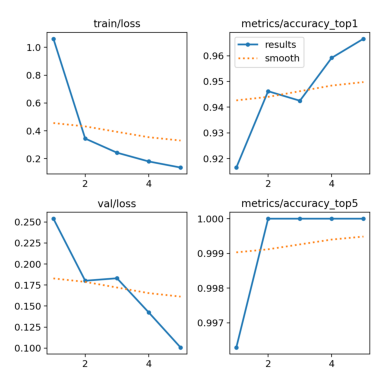

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/classify/train/results.png")
plt.imshow(img)
plt.axis("off")